# Đo hiệu năng trên Raspberry Pi 5

Notebook tổng hợp số đo trên Raspberry Pi 5 dùng trong báo cáo tuần 7 (`docs/report/chapters/w7-onnx.md`
mục 2.3) và chương 5. Mọi bảng tính từ log commit trong `src/ml/experiments/`:

| Thư mục | Nội dung | Script |
|---|---|---|
| `pi5_anh_that/` | 50 ảnh camera cổng, 2 cấu hình kiểu dáng, log điện năng | `run_pi_anh_that.sh` |
| `pi5_do_tre_api/` | Độ trễ đầu-cuối qua `POST /captures/infer` | `run_pi_do_tre_api.sh` |
| `anh_that_dev/` | Cùng 50 ảnh chạy trên máy dev, để so kết quả nhận dạng | `benchmark_anh_that.py` |
| `pi5/` | Ma trận số luồng và bản định vị xe trên ảnh mẫu | `run_pi_benchmark.sh` |

## 0. Setup

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve().parents[2] if Path.cwd().name == "notebooks" else Path.cwd()
EXP = REPO_ROOT / "src" / "ml" / "experiments"
ANH, API, DEV, MA_TRAN = EXP / "pi5_anh_that", EXP / "pi5_do_tre_api", EXP / "anh_that_dev", EXP / "pi5"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"

CAU_HINH = {"pt_mnv3": "MobileNetV3-Small", "pt_resnet": "ResNet18"}
MAU = {"pt_mnv3": "#009E73", "pt_resnet": "#0072B2"}
NHOM = {"o_to": "ô tô", "xe_may": "xe máy"}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True, "font.size": 10})


def so_vn(x, n=1):
    return f"{x:,.{n}f}".replace(",", "_").replace(".", ",").replace("_", ".")


anh = {ch: pd.read_csv(ANH / f"{ch}.csv") for ch in CAU_HINH}

## 1. Máy đo và cách đo

**Máy.** Raspberry Pi 5, cấu hình ghi trong `pi5/may_do.txt` (cùng máy, cùng ngày đo). Model thật sự
chạy đọc từ đầu log mỗi lần đo.

**Ảnh.** 50 ảnh camera cổng thật, 25 ô tô (`carlong_`) và 25 xe máy (`greenpack_`), lấy ngẫu nhiên
với seed 2026 từ tập val của `kaggle_vn_plate_segment`. Danh sách ở `src/ml/data/anh_cong_benchmark.txt`.

**Thời gian suy luận.** `benchmark_anh_that.py` nạp hết ảnh vào bộ nhớ, làm nóng 3 ảnh, rồi gọi
`OnnxAlprPipeline.run()` 5 vòng mỗi ảnh bằng `time.perf_counter()`. Lấy trung vị 5 vòng của từng ảnh,
rồi báo trung vị và phân vị 90 trên các ảnh.

**Độ trễ đầu-cuối.** `do_tre_api.py` gọi `POST /captures/infer` của backend thật trên Pi (bản riêng trỏ
bản sao cơ sở dữ liệu), 3 vòng mỗi ảnh, đo từ lúc gửi tới lúc nhận phản hồi. Phản hồi có
`timings_ms.tong` là tổng thời gian các bước pipeline có bấm giờ, nên phần ngoài suy luận tính trên cùng request:

$$t_{\text{ngoài suy luận}} = t_{\text{client}} - \texttt{timings\_ms.tong}$$

Phần này gồm HTTP, giải mã ảnh, lưu ảnh, ghi cơ sở dữ liệu và đoạn code không bấm giờ giữa các bước.

**Điện năng.** Chip quản lý nguồn của Pi 5 có ADC đo dòng và áp từng nhánh, đọc bằng
`vcgencmd pmic_read_adc` mỗi giây: $P = \sum_k V_k I_k$. Trong mốc thời gian của mỗi cấu hình chỉ có
vòng gọi `run()`, nên

$$E_{\text{mỗi lượt}} = \frac{\bar P \times \Delta t}{\text{số lượt}} \qquad
E_{\text{tăng thêm}} = \frac{(\bar P - P_{\text{nghỉ}}) \times \Delta t}{\text{số lượt}}$$

với $P_{\text{nghỉ}}$ là trung vị các mẫu trong hai lần nghỉ 60 giây đầu và cuối. Số này là cận dưới
của điện năng ở ổ cắm vì không tính củ sạc và thiết bị USB.

**Nhiệt độ và hạ xung.** Cùng script ghi nhiệt độ SoC, xung CPU và `vcgencmd get_throttled` mỗi giây.
Bit 0 đến 3 lần lượt báo sụt áp, đang giới hạn xung, đang hạ xung, chạm ngưỡng nhiệt mềm. Trước mỗi cấu
hình và trước lần đo API, script chờ tới khi phần nguyên nhiệt độ SoC không quá 58°C, tối đa 5 phút.

In [2]:
may_do = dict(d.split(": ", 1) for d in (MA_TRAN / "may_do.txt").read_text(encoding="utf-8").splitlines() if ": " in d)
dau_log = {ch: dict(re.findall(r"^\s*(Định vị xe|Kiểu dáng xe|ML_INTRAOP_THREADS)\s*[:=]\s*(\S+)",
                                (ANH / f"{ch}.log").read_text(encoding="utf-8"), re.M)) for ch in CAU_HINH}
display(pd.DataFrame([
    ("Thiết bị", may_do["model"]), ("RAM", f"{int(may_do['ram_mb']) / 1024:.0f} GB"),
    ("Hệ điều hành", may_do["he_dieu_hanh"]), ("Ổ đĩa", "thẻ microSD"), ("Nguồn khai báo", f"{may_do['nguon_max_ma']} mA"),
    *[(f"Cấu hình {ch}", f"định vị {v['Định vị xe']}, kiểu dáng {v['Kiểu dáng xe']}, {v['ML_INTRAOP_THREADS']} luồng")
      for ch, v in dau_log.items()],
], columns=["Mục", "Giá trị"]).style.hide(axis="index"))

Mục,Giá trị
Thiết bị,Raspberry Pi 5 Model B Rev 1.1
RAM,16 GB
Hệ điều hành,Debian GNU/Linux 13 (trixie)
Ổ đĩa,thẻ microSD
Nguồn khai báo,3000 mA
Cấu hình pt_mnv3,"định vị yolov8n.pt, kiểu dáng vehicle-style-mobilenet_v3_small.onnx, 4 luồng"
Cấu hình pt_resnet,"định vị yolov8n.pt, kiểu dáng vehicle-style-resnet18.onnx, 4 luồng"


## 2. Thời gian suy luận trên 50 ảnh

Kiểu dáng,Ảnh,Số ảnh,Trung vị (ms),p90 (ms),Max (ms)
MobileNetV3-Small,tất cả,50,464.4,487.7,502.8
MobileNetV3-Small,ô tô,25,479.1,495.4,502.8
MobileNetV3-Small,xe máy,25,461.5,467.1,472.9
ResNet18,tất cả,50,463.0,539.1,548.2
ResNet18,ô tô,25,530.0,542.0,548.2
ResNet18,xe máy,25,460.6,465.7,474.8


So từng ảnh, chênh = ResNet18 trừ MobileNetV3-Small:

,Số ảnh,MobileNetV3-Small (ms),ResNet18 (ms),Chênh trung vị (ms),Chênh min (ms),Chênh max (ms)
không qua bước kiểu dáng,32,461.4,459.5,-1.9,-18.7,12.5
có qua bước kiểu dáng,18,482.0,536.4,51.3,30.6,68.5


Trung vị trên 50 ảnh theo từng vòng:

,MobileNetV3-Small,ResNet18
vòng 1,469.1,464.6
vòng 2,468.9,467.9
vòng 3,467.1,462.8
vòng 4,468.1,462.8
vòng 5,468.4,472.2


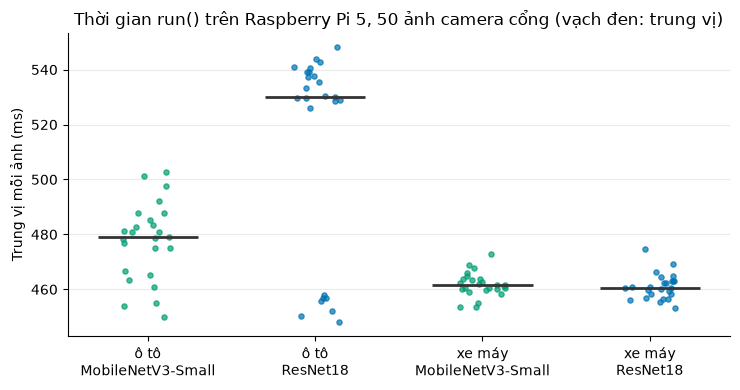

In [3]:
hang = []
for ch, df in anh.items():
    for nhan, sub in [("tất cả", df)] + [(v, df[df.nhom == k]) for k, v in NHOM.items()]:
        hang.append((CAU_HINH[ch], nhan, len(sub), sub.trung_vi_ms.median(),
                     np.percentile(sub.trung_vi_ms, 90), sub.trung_vi_ms.max()))
bang = pd.DataFrame(hang, columns=["Kiểu dáng", "Ảnh", "Số ảnh", "Trung vị (ms)", "p90 (ms)", "Max (ms)"])
display(bang.style.hide(axis="index").format(precision=1))

gop = anh["pt_mnv3"].merge(anh["pt_resnet"], on="anh", suffixes=("_mnv3", "_resnet"))
assert (gop.kieu_dang_mnv3.notna() == gop.kieu_dang_resnet.notna()).all()
gop["chenh"] = gop.trung_vi_ms_resnet - gop.trung_vi_ms_mnv3
so_sanh = gop.groupby(gop.kieu_dang_mnv3.notna()).agg(
    so_anh=("anh", "size"), mnv3=("trung_vi_ms_mnv3", "median"), resnet=("trung_vi_ms_resnet", "median"),
    chenh_trung_vi=("chenh", "median"), chenh_min=("chenh", "min"), chenh_max=("chenh", "max"))
so_sanh.index = so_sanh.index.map({True: "có qua bước kiểu dáng", False: "không qua bước kiểu dáng"}).rename(None)
so_sanh.columns = ["Số ảnh", "MobileNetV3-Small (ms)", "ResNet18 (ms)", "Chênh trung vị (ms)", "Chênh min (ms)", "Chênh max (ms)"]
display(Markdown("So từng ảnh, chênh = ResNet18 trừ MobileNetV3-Small:"))
display(so_sanh.style.format(precision=1))
display(Markdown("Trung vị trên 50 ảnh theo từng vòng:"))
display(pd.DataFrame({CAU_HINH[ch]: [df[f"vong_{i}_ms"].median() for i in range(1, 6)] for ch, df in anh.items()},
                     index=[f"vòng {i}" for i in range(1, 6)]).style.format(precision=1))

fig, ax = plt.subplots(figsize=(7.5, 4))
rng = np.random.default_rng(0)
vi_tri = 0
nhan_truc = []
for k, v in NHOM.items():
    for ch in CAU_HINH:
        y = anh[ch][anh[ch].nhom == k].trung_vi_ms
        ax.scatter(vi_tri + rng.uniform(-0.15, 0.15, len(y)), y, s=14, color=MAU[ch], alpha=0.7)
        ax.hlines(y.median(), vi_tri - 0.3, vi_tri + 0.3, color="#333333", lw=2)
        nhan_truc.append(f"{v}\n{CAU_HINH[ch]}")
        vi_tri += 1
ax.set_xticks(range(vi_tri), nhan_truc)
ax.set_ylabel("Trung vị mỗi ảnh (ms)")
ax.set_title("Thời gian run() trên Raspberry Pi 5, 50 ảnh camera cổng (vạch đen: trung vị)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "pi5_anh_that.png", dpi=150, bbox_inches="tight")
plt.show()

Trên cả 50 ảnh, hai cấu hình có trung vị gần bằng nhau (464,4 và 463,0 ms) nhưng phân vị 90 khác rõ
(487,7 và 539,1 ms). Khác biệt nằm ở bước kiểu dáng: bước này chỉ chạy khi model loại xe trả `car` và
bước định vị tìm được vùng xe, tức 18/50 ảnh, trùng nhau ở hai cấu hình.

So từng ảnh, trên 18 ảnh đó ResNet18 chậm hơn MobileNetV3-Small từ 30,6 đến 68,5 ms (trung vị 51,3 ms).
Trên 32 ảnh không qua bước kiểu dáng, hai lần chạy lệch từ -18,7 đến 12,5 ms, là dao động giữa hai
lần chạy.

Trung vị theo từng vòng nằm trong khoảng 467 đến 469 ms (MobileNetV3-Small) và 463 đến 472 ms
(ResNet18), không tăng dần theo vòng.

## 3. Độ trễ đầu-cuối qua API

In [4]:
api = pd.read_csv(API / "do_tre_api.csv")
ok = api[api.http == 200]
theo_anh = ok.groupby("anh")[["ms", "suy_luan_backend_ms", "ngoai_suy_luan_ms"]].median()
luot_dau = dict(l.split("=") for l in (API / "do_tre_api_luot_dau.txt").read_text().split())
dien_api = pd.read_csv(API / "nhat_ky_dien.csv")
co_api = int(((dien_api.throttled.map(lambda s: int(s, 16)) & 0xF) != 0).sum())
display(Markdown(f"{len(api)} lượt, {len(api) - len(ok)} lượt lỗi HTTP. "
                 f"Lượt đầu tiên sau khi khởi động backend: **{so_vn(float(luot_dau['luot_dau_ms']) / 1000)} giây**. "
                 f"Log điện {so_vn(dien_api.t_unix.iloc[-1] - dien_api.t_unix.iloc[0])} giây, nhiệt độ "
                 f"{so_vn(dien_api.nhiet_do_c.iloc[0])} đến {so_vn(dien_api.nhiet_do_c.max())}°C, "
                 f"mẫu bật bit 0 đến 3: {co_api}/{len(dien_api)}."))
display(pd.DataFrame({
    "Phần": ["Đầu-cuối phía client", "Các bước suy luận (timings_ms.tong)", "Ngoài suy luận (cùng request)"],
    "Trung vị (ms)": [theo_anh[c].median() for c in theo_anh],
    "p90 (ms)": [np.percentile(theo_anh[c], 90) for c in theo_anh],
    "Max (ms)": [theo_anh[c].max() for c in theo_anh],
}).style.hide(axis="index").format(precision=1))

150 lượt, 0 lượt lỗi HTTP. Lượt đầu tiên sau khi khởi động backend: **4,8 giây**. Log điện 77,4 giây, nhiệt độ 57,3 đến 77,7°C, mẫu bật bit 0 đến 3: 0/76.

Phần,Trung vị (ms),p90 (ms),Max (ms)
Đầu-cuối phía client,463.4,487.9,497.2
Các bước suy luận (timings_ms.tong),445.8,465.8,475.3
Ngoài suy luận (cùng request),17.5,22.1,29.1


Đầu-cuối qua API mất 463,4 ms mỗi lượt, phân vị 90 là 487,9 ms. Trên cùng request, các bước pipeline
có bấm giờ chiếm 445,8 ms; phần còn lại 17,5 ms gồm HTTP, giải mã ảnh, lưu ảnh, ghi cơ sở dữ liệu và
đoạn code không bấm giờ giữa các bước. Client và backend chạy cùng máy nên chưa gồm mạng LAN.

Lượt đầu tiên sau khi khởi động backend mất 4,8 giây vì backend nạp model ở lượt chụp đầu. Trong 77
giây đo không mẫu nào bật bit 0 đến 3 của `get_throttled`.

## 4. Điện năng

Công suất nghỉ: **1,55 W**.

Kiểu dáng,Số lượt,Thời gian đo (s),Số mẫu điện,P trung bình (W),E mỗi lượt (J),E tăng thêm (J)
MobileNetV3-Small,250,118.14,114,6.60,3.12,2.39
ResNet18,250,122.28,118,6.64,3.25,2.49


Kiểu dáng,Giây từ mốc trước,Nhiệt độ thấp nhất 5 phút trước (°C),Nhiệt độ cao nhất trong mốc (°C),Mẫu bật bit 0-2,Mẫu bật bit 3,Xung thấp nhất (MHz)
MobileNetV3-Small,5.7,57.9,82.6,0,3,2400
ResNet18,307.2,59.5,83.2,0,13,2400


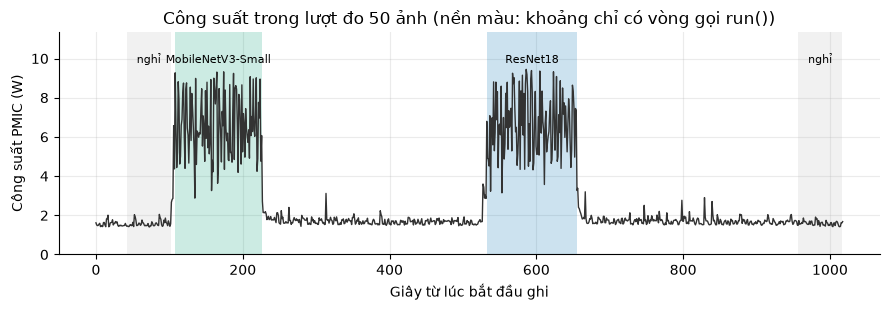

In [5]:
dien = pd.read_csv(ANH / "nhat_ky_dien.csv")
moc = pd.read_csv(ANH / "moc_thoi_gian.csv").set_index("nhan")


def mau(nhan):
    t0, t1 = moc.loc[nhan, ["t_bat_dau", "t_ket_thuc"]]
    return dien[(dien.t_unix >= t0) & (dien.t_unix <= t1)]


p_nghi = pd.concat([mau("nghi_truoc"), mau("nghi_sau")]).p_tong_w.median()
hang, hang_nhiet = [], []
for ch in CAU_HINH:
    so_luot = int(dict(l.split("=") for l in (ANH / f"{ch}_moc.txt").read_text().split())["so_luot"])
    t0, t1 = moc.loc[ch, ["t_bat_dau", "t_ket_thuc"]]
    m = mau(ch)
    p_tb = m.p_tong_w.mean()
    hang.append((CAU_HINH[ch], so_luot, t1 - t0, len(m), p_tb, p_tb * (t1 - t0) / so_luot, (p_tb - p_nghi) * (t1 - t0) / so_luot))
    # Chỉ bit 3 bật mà xung vẫn tối đa thì CPU chưa chạy chậm lại
    co = m.throttled.map(lambda s: int(s, 16))
    truoc = dien[(dien.t_unix >= t0 - 300) & (dien.t_unix < t0)]
    hang_nhiet.append((CAU_HINH[ch], t0 - moc.t_ket_thuc[moc.t_ket_thuc <= t0].max(), truoc.nhiet_do_c.min(),
                       m.nhiet_do_c.max(), int(((co & 0x7) != 0).sum()), int(((co & 0x8) != 0).sum()), m.xung_mhz.min()))
display(Markdown(f"Công suất nghỉ: **{so_vn(p_nghi, 2)} W**."))
display(pd.DataFrame(hang, columns=["Kiểu dáng", "Số lượt", "Thời gian đo (s)", "Số mẫu điện",
                                    "P trung bình (W)", "E mỗi lượt (J)", "E tăng thêm (J)"])
        .style.hide(axis="index").format(precision=2))
display(pd.DataFrame(hang_nhiet, columns=["Kiểu dáng", "Giây từ mốc trước", "Nhiệt độ thấp nhất 5 phút trước (°C)",
                                          "Nhiệt độ cao nhất trong mốc (°C)", "Mẫu bật bit 0-2", "Mẫu bật bit 3",
                                          "Xung thấp nhất (MHz)"])
        .style.hide(axis="index").format(precision=1))

fig, ax = plt.subplots(figsize=(9, 3.2))
t0 = dien.t_unix.iloc[0]
ax.plot(dien.t_unix - t0, dien.p_tong_w, color="#333333", lw=1)
for nhan, r in moc.iterrows():
    mau_nen = MAU.get(nhan, "#BBBBBB")
    ax.axvspan(r.t_bat_dau - t0, r.t_ket_thuc - t0, color=mau_nen, alpha=0.2, lw=0)
    ax.text((r.t_bat_dau + r.t_ket_thuc) / 2 - t0, dien.p_tong_w.max() * 1.02,
            CAU_HINH.get(nhan, "nghỉ"), ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, dien.p_tong_w.max() * 1.2)
ax.set_xlabel("Giây từ lúc bắt đầu ghi")
ax.set_ylabel("Công suất PMIC (W)")
ax.set_title("Công suất trong lượt đo 50 ảnh (nền màu: khoảng chỉ có vòng gọi run())")
fig.tight_layout()
fig.savefig(FIG_DIR / "pi5_dien_nang.png", dpi=150, bbox_inches="tight")
plt.show()

Mỗi lượt xe tốn 3,12 J với MobileNetV3-Small và 3,25 J với ResNet18, trong đó 2,39 và 2,49 J là phần
tăng thêm so với lúc nghỉ. Số đọc từ PMIC nên là cận dưới của điện năng ở ổ cắm.

Sau 1 đến 2 phút tải liên tục SoC lên 82 đến 83°C và bật bit 3 (chạm ngưỡng nhiệt mềm) ở 3/114 và
13/118 mẫu. Không mẫu nào bật bit 0 đến 2, xung CPU thấp nhất trong cả hai mốc vẫn là 2400 MHz, và
trung vị từng vòng ở mục 2 không tăng dần, nên số thời gian của lần đo này vẫn dùng được.

Trước MobileNetV3-Small, SoC đã nguội xuống 57,9°C trong lần nghỉ đầu. Trước ResNet18, script chờ hết
giới hạn 5 phút mà nhiệt độ thấp nhất chỉ 59,5°C, chưa đạt điều kiện 58°C.

## 5. Kết quả nhận dạng trên Pi so với máy dev

In [6]:
hang = []
for ch in CAU_HINH:
    gop = anh[ch].merge(pd.read_csv(DEV / f"{ch}_4luong.csv"), on="anh", suffixes=("_pi", "_dev"))
    hang.append((CAU_HINH[ch], len(gop), *[int((gop[f"{t}_pi"].fillna("") == gop[f"{t}_dev"].fillna("")).sum())
                                            for t in ("bien", "loai_xe", "kieu_dang")]))
display(pd.DataFrame(hang, columns=["Kiểu dáng", "Số ảnh", "Chuỗi biển khớp", "Loại xe khớp", "Kiểu dáng khớp"])
        .style.hide(axis="index"))

Kiểu dáng,Số ảnh,Chuỗi biển khớp,Loại xe khớp,Kiểu dáng khớp
MobileNetV3-Small,50,50,50,50
ResNet18,50,50,50,50


Chuỗi biển, loại xe và kiểu dáng trên Pi trùng máy dev ở cả 50/50 ảnh, cho cả hai cấu hình. Model chạy
trên ARM không làm lệch kết quả nhận dạng.

## 6. Chọn số luồng và bản định vị xe

Lần đo này dùng ảnh mẫu `1_bomaich_detect.png` (xe máy, 12 biển), trung vị 10 lượt `run()` mỗi cấu hình,
log ở `pi5/`. Chỉ dùng để so các cấu hình với nhau, không dùng làm thời gian mỗi lượt xe.

In [7]:
th = pd.read_csv(MA_TRAN / "tong_hop.csv")
b = th[th.loat.str.startswith("bench_")]
ma_tran = b.pivot_table(index="cau_hinh", columns="luong", values="trung_vi_ms").loc[["pt", "onnx", "onnx_mnv3"]]
ma_tran.index = ["định vị .pt, ResNet18", "định vị .onnx, ResNet18", "định vị .onnx, MobileNetV3-Small"]
ma_tran.columns = [f"{int(c)} luồng (ms)" for c in ma_tran.columns]
display(ma_tran.style.format("{:.1f}"))
display(Markdown(f"Model thật sự chạy khớp tên cấu hình ở {int((b.dinh_vi_file.notna()).sum())}/{len(b)} loạt (đọc từ đầu log)."))

ram = {p.stem.removeprefix("ram_"): int(re.search(r"ru_maxrss_kb=(\d+)", p.read_text(encoding="utf-8")).group(1)) / 1024
       for p in sorted(MA_TRAN.glob("ram_*.log"))}
display(Markdown("Bộ nhớ tối đa của tiến trình chạy `benchmark_pipeline.py` (`ru_maxrss`, `run_pi_ram.sh`):"))
display(pd.DataFrame({"Loạt": list(ram), "RSS tối đa (MiB)": list(ram.values())}).style.hide(axis="index").format(precision=1))

,1 luồng (ms),2 luồng (ms),4 luồng (ms)
"định vị .pt, ResNet18",813.9,526.3,495.3
"định vị .onnx, ResNet18",1067.4,611.6,535.0
"định vị .onnx, MobileNetV3-Small",1082.4,610.9,550.4


Model thật sự chạy khớp tên cấu hình ở 9/9 loạt (đọc từ đầu log).

Bộ nhớ tối đa của tiến trình chạy `benchmark_pipeline.py` (`ru_maxrss`, `run_pi_ram.sh`):

Loạt,RSS tối đa (MiB)
onnx_4luong,741.7
onnx_mnv3_4luong,705.4
pt_4luong,766.3


4 luồng nhanh nhất ở cả ba cấu hình. Bản `.onnx` của bước định vị xe chậm hơn bản `.pt` (1.067,4 so với
813,9 ms ở 1 luồng, 535,0 so với 495,3 ms ở 4 luồng), nên backend trên Pi dùng `.pt` và 4 luồng. Hai
dòng `.onnx` gần như bằng nhau vì ảnh mẫu là xe máy, bước kiểu dáng không chạy.

Bộ nhớ tối đa của tiến trình đo là 705 đến 766 MiB. Tiến trình này nạp pipeline hai lần và nạp thêm các
model đo riêng nên đây là cận trên; cấu hình `.pt` + MobileNetV3-Small chưa được đo riêng. Máy có 16GB RAM.

## 7. Tổng kết

- Đạt mốc đề cương: đầu-cuối qua API 463,4 ms mỗi lượt (phân vị 90 là 487,9 ms) trên 50 ảnh camera
  cổng, nhanh hơn mốc 2 giây khoảng 4 lần.
- Cấu hình trên Pi: 4 luồng, định vị xe `.pt`, kiểu dáng MobileNetV3-Small ONNX. Trên mỗi ảnh có qua
  bước kiểu dáng, nhanh hơn ResNet18 trung vị 51,3 ms.
- Điện năng 3,12 J mỗi lượt xe, cận dưới của điện năng ở ổ cắm.
- Kết quả nhận dạng trên Pi trùng máy dev 50/50 ảnh.

Chưa đo: tải liên tục lâu hơn 2 phút, độ trễ mạng LAN, điện năng ở ổ cắm bằng đồng hồ rời.